# 07 - Generalisation

How does the classifier hold up on simulations it was not trained on?

Two out-of-distribution (OOD) splits are evaluated:

- **`cross_softening`**: trained on `wdm_512_z39_fixed`, tested on `wdm_512_z39_adapt`. They have the same initial conditions, but different force softening.
- **`cross_z_ini`**: trained on `wdm_512_z39_fixed`, tested on `wdm_512_z99_fixed`. They have the same softening, but an earlier initial redshift.

The `cross_z_ini` split is the most scientifically interesting.

Figure 7 of Mostoghiu Paun et al. (2025) suggested that the empirical sphericity relation derived at $z_{\rm ini} = 39$ transfers poorly to $z_{\rm ini} = 99$, where earlier initialisation is associated with lower protohalo sphericities (~6% decrease).

A structured classifier failure was therefore plausible, but did not appear in these experiments. This notebook examines likely reasons.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mlflow")

from __future__ import annotations

import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mlflow
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
)


from src.config import load_config
from src.db import get_connection
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()
conn = get_connection(cfg.database_path, read_only=True)
mlflow.set_tracking_uri(cfg.mlflow.tracking_uri)

FIGURES_DIR = Path("reports/figures")

In [2]:
# Feature columns, must match the order used during training.
FEATURE_COLS: list[str] = [
    'log10_m200',
    'log10_npart',
    'x_norm',
    'y_norm',
    'z_norm',
    'v_disp_sigv',
    'concentration_cNFW',
    'spin_bullock',
    'axis_ratio_b_over_a',
    'axis_ratio_c_over_a',
    'sphericity_s',
    'log10_m_hmm',
    'a_hmm',
    'dist_nearest_neighbour_mpc_h',
    'count_neighbours_within_radius_mpc_h',
]

MODEL_ORDER = ['lr', 'rf', 'gbm', 'ensemble']
SPLIT_ORDER = ['within_sim', 'cross_softening', 'cross_z_ini']

MODEL_LABELS = {'lr': 'LR', 'rf': 'RF', 'gbm': 'GBM', 'ensemble': 'Ensemble'}
SPLIT_LABELS = {
    'within_sim':      'Within-sim',
    'cross_softening': 'Cross-softening',
    'cross_z_ini':     r'Cross-$z_{\rm ini}$',
}

SIM_IDS = {
    'z39_fixed': 'wdm_512_z39_fixed',
    'z39_adapt': 'wdm_512_z39_adapt',
    'z99_fixed': 'wdm_512_z99_fixed',
}


## 1. Performance summary

In [3]:
# Load test-set metrics from MLflow.
runs_df = mlflow.search_runs(
    search_all_experiments=True,
    filter_string="attributes.status = 'FINISHED'",
)
required = {'params.model', 'params.split_name'}
metric_candidates = {
    'ap':      ['metrics.test_average_precision', 'metrics.average_precision'],
    'roc_auc': ['metrics.test_roc_auc', 'metrics.roc_auc'],
    'f1':      ['metrics.test_f1', 'metrics.f1'],
}
selected_metric_cols = {}
for target_name, candidates in metric_candidates.items():
    source_col = next((col for col in candidates if col in runs_df.columns), None)
    if source_col is None:
        raise ValueError(f'MLflow runs missing {target_name} metric column.')
    selected_metric_cols[target_name] = source_col
required = required.union(selected_metric_cols.values())
if not required.issubset(runs_df.columns) or runs_df.empty:
    raise ValueError('MLflow runs missing expected columns.')
metrics_df = runs_df[list(required)].rename(columns={
    'params.model':      'model',
    'params.split_name': 'split',
    selected_metric_cols['ap']: 'ap',
    selected_metric_cols['roc_auc']: 'roc_auc',
    selected_metric_cols['f1']: 'f1',
}).dropna()
print(f'Loaded {len(metrics_df)} MLflow runs.')

metrics_df


Loaded 18 MLflow runs.


,model,roc_auc,f1,ap,split
0,mlp_mask,0.939283,0.947150,0.980233,cross_z_ini
1,mlp_impute,0.940178,0.935654,0.980484,cross_z_ini
2,mlp_mask,0.918518,0.942500,0.971579,cross_softening
3,mlp_impute,0.919526,0.935687,0.969415,cross_softening
4,mlp_mask,0.953386,0.946435,0.986471,within_sim
5,mlp_impute,0.952973,0.943866,0.986194,within_sim
6,ensemble,0.941394,0.958947,0.981045,cross_z_ini
7,gbm,0.943413,0.964586,0.981670,cross_z_ini
8,rf,0.946115,0.958752,0.982771,cross_z_ini
9,lr,0.930330,0.929826,0.977266,cross_z_ini


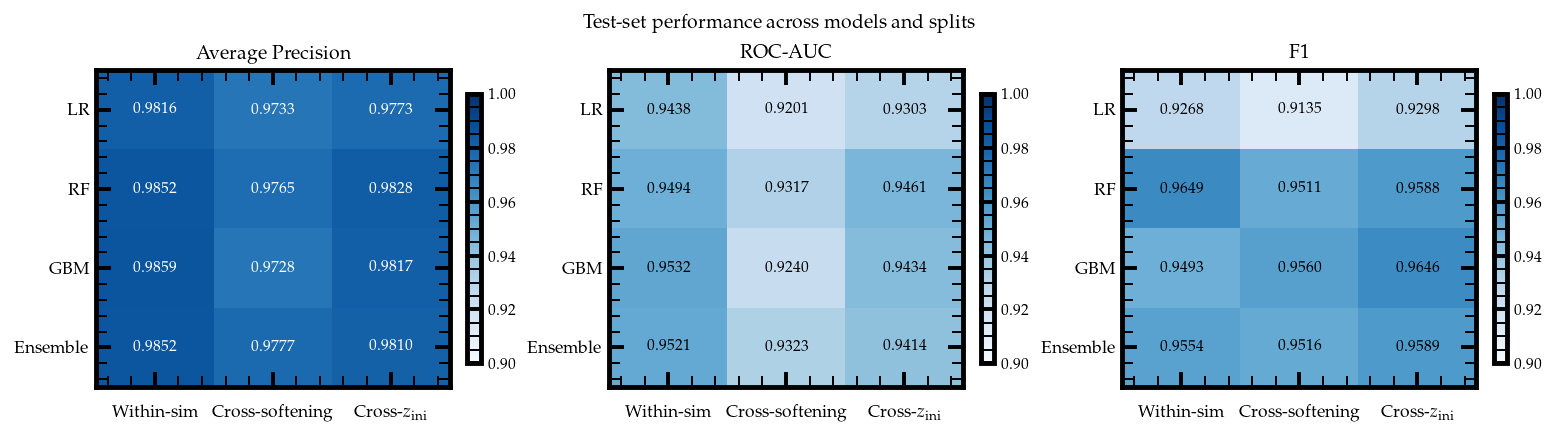

In [4]:
# Generalisation heatmap, one panel per metric.
METRICS = [
    ('ap',      'Average Precision'),
    ('roc_auc', 'ROC-AUC'),
    ('f1',      'F1'),
]

fig, axes = plt.subplots(
    1, 3, figsize=(11, 3),
    constrained_layout=True,
)

for ax, (metric_key, metric_label) in zip(axes, METRICS):
    pivot = (
        metrics_df
        .pivot(index='model', columns='split', values=metric_key)
        .reindex(index=MODEL_ORDER, columns=SPLIT_ORDER)
    )
    data = pivot.values.astype(float)

    im = ax.imshow(data, vmin=0.90, vmax=1.00, cmap='Blues', aspect='auto')
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    _ = cbar.ax.tick_params(labelsize=8)

    for i in range(len(MODEL_ORDER)):
        for j in range(len(SPLIT_ORDER)):
            val = data[i, j]
            text_col = 'white' if val > 0.965 else 'black'
            _ = ax.text(
                j, i, f'{val:.4f}',
                ha='center', va='center', fontsize=8, color=text_col,
            )

    _ = ax.set_xticks(range(len(SPLIT_ORDER)))
    _ = ax.set_xticklabels(
        [SPLIT_LABELS[s] for s in SPLIT_ORDER], fontsize=9,
    )
    _ = ax.set_yticks(range(len(MODEL_ORDER)))
    _ = ax.set_yticklabels(
        [MODEL_LABELS[m] for m in MODEL_ORDER], fontsize=9,
    )
    _ = ax.set_title(metric_label, fontsize=10)

fig.suptitle(
    'Test-set performance across models and splits',
    fontsize=10,
)

fig.savefig(FIGURES_DIR / "07_generalisation_heatmap.png", dpi=200, bbox_inches="tight")


**Observations**

- All models generalise well in this benchmark. Average precision remains above 0.97 across splits.
- `cross_softening` shows a larger AP drop than `cross_z_ini` for most models, even though a softening change is arguably a smaller physical perturbation than changing the initial redshift. Section 5 discusses plausible contributors.
- RF appears to generalise best in these runs: it outperforms GBM on both OOD splits despite trailing on `within_sim`. The cross-split grid selected shallower, more regularised trees (`max_depth=10`, `n_estimators=200`) compared to the `within_sim` grid (`max_depth=20`, `n_estimators=1000`).
- The ensemble adds little incremental value in this setting, consistent with high correlation among base-model predictions.

## 2. Feature distribution shift

Before asking where the classifier fails, we need to know whether the feature distributions actually shift between the train and test simulations. 

A large shift in a high-importance feature is the most plausible explanation for performance degradation.

In [5]:
# Load WDM features and labels for the three relevant simulations.
# CDM haloes are excluded, as is_spurious_cdm_match is null for them.
feat_cols_sql = ', '.join(f'f.{c}' for c in FEATURE_COLS)

frames: dict[str, pd.DataFrame] = {}
for label, sim_id in SIM_IDS.items():
    query = f"""
        SELECT
            f.halo_id,
            f.simulation_id,
            {feat_cols_sql},
            l.is_spurious_cdm_match
        FROM gold.features f
        JOIN gold.labels l
            ON f.halo_id = l.halo_id
           AND f.simulation_id = l.simulation_id
        WHERE f.simulation_id = '{sim_id}'
          AND l.is_spurious_cdm_match IS NOT NULL
    """
    frames[label] = conn.execute(query).df()
    print(f'{label} ({sim_id}): {len(frames[label]):,} labelled WDM haloes')


z39_fixed (wdm_512_z39_fixed): 18,579 labelled WDM haloes
z39_adapt (wdm_512_z39_adapt): 19,467 labelled WDM haloes
z99_fixed (wdm_512_z99_fixed): 18,426 labelled WDM haloes


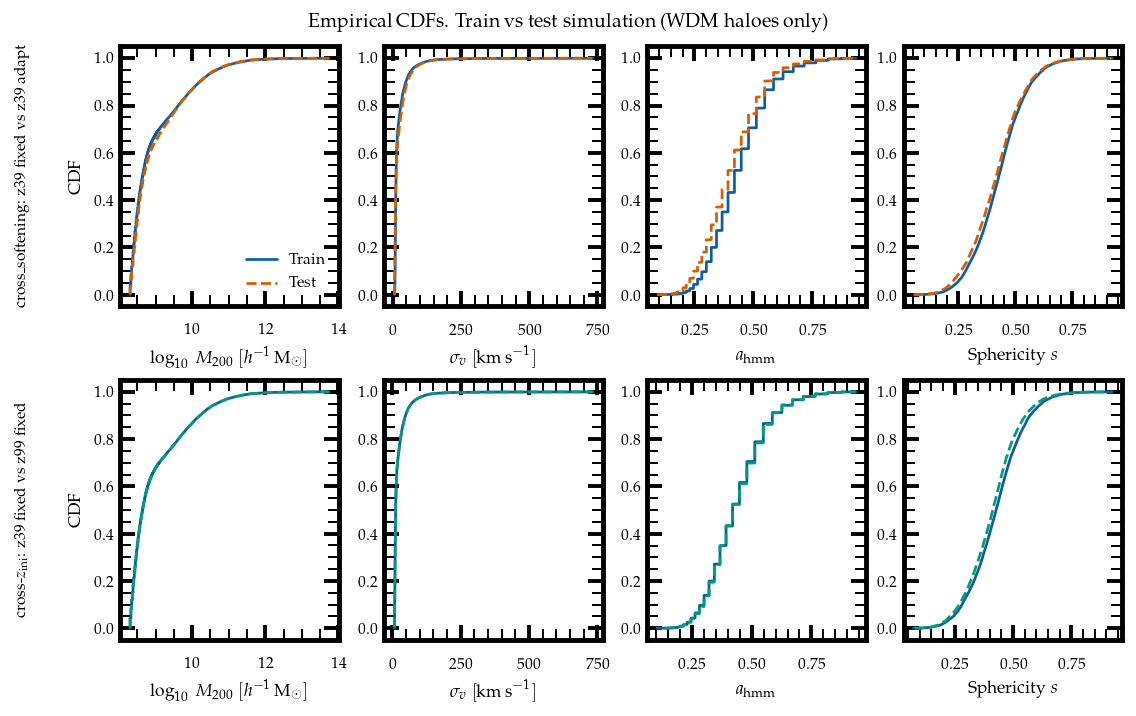

In [6]:
# Empirical CDFs for the four most diagnostically informative features.
# Top row: cross_softening shift. Bottom row: cross_z_ini shift.
DIST_FEATURES = ['log10_m200', 'v_disp_sigv', 'a_hmm', 'sphericity_s']
FEAT_XLABELS = [
    r'$\log_{10}\,M_{200}\ [h^{-1}\,{\rm M}_\odot]$',
    r'$\sigma_v\ [{\rm km\,s}^{-1}]$',
    r'$a_{\rm hmm}$',
    r'Sphericity $s$',
]

_comparisons = [
    (r'cross\_softening: z39 fixed vs z39 adapt', 'z39_fixed', 'z39_adapt', '#D55E00'),
    (r'cross-$z_{\rm ini}$: z39 fixed vs z99 fixed', 'z39_fixed', 'z99_fixed', '#009E73'),
]

fig, axes = plt.subplots(
    2, 4, figsize=(8, 5),
    constrained_layout=True,
)

for row_idx, (row_label, sim_a, sim_b, test_colour) in enumerate(_comparisons):
    for col_idx, (feat, xlabel) in enumerate(zip(DIST_FEATURES, FEAT_XLABELS)):
        ax = axes[row_idx, col_idx]

        for sim_key, color, ls, lbl in [
            (sim_a, '#0C5DA5', '-',  'Train'),
            (sim_b, test_colour, '--', 'Test'),
        ]:
            vals = frames[sim_key][feat].dropna().values
            if len(vals) == 0:
                continue
            sv = np.sort(vals)
            cdf = np.arange(1, len(sv) + 1) / len(sv)
            _ = ax.plot(sv, cdf, color=color, linestyle=ls,
                        linewidth=1.4, label=lbl)

        _ = ax.set_xlabel(xlabel, fontsize=9)
        if col_idx == 0:
            _ = ax.set_ylabel('CDF', fontsize=9)
        _ = ax.tick_params(labelsize=8)
        if row_idx == 0 and col_idx == 0:
            _ = ax.legend(fontsize=8)

    # Row label on the left.
    _ = axes[row_idx, 0].annotate(
        row_label, xy=(-0.45, 0.5),
        xycoords='axes fraction',
        fontsize=8, rotation=90, va='center', ha='center',
    )

_ = fig.suptitle(
    'Empirical CDFs. Train vs test simulation (WDM haloes only)',
    fontsize=10,
)


**What the CDFs reveal**

- **`cross_softening` (top row)**: `log10_m200` and `v_disp_sigv` distributions are very similar between z39 fixed and z39 adaptive, as expected from shared initial conditions. The clearest visible shift is in `a_hmm` (formation time): the tidal adaptive run forms haloes slightly earlier on average, consistent with Figure 5 of the paper ($\Delta\bar{a}_{\rm hmm} \approx 0.03$).

- **`cross_z_ini` (bottom row)**: `sphericity_s` shifts to lower values in z99 runs (~6% lower mean, consistent with Figure 7 of the paper), while `log10_m200` and `v_disp_sigv` remain similar.

A working interpretation is that, because `a_hmm` has low SHAP importance (~rank 7-8 in notebook 06) and `sphericity_s` is near the bottom of the importance rankings, neither shift alone is likely to induce a severe failure. The dominant classifier signals (`log10_m200`, `v_disp_sigv`) appear relatively stable across both splits, which is consistent with the observed robustness.

## 3. Error analysis

We load the RF model for each OOD split and examine where it makes mistakes. RF is used throughout because it generalises best across splits.

In [7]:
# Helper: load test set for a given split from gold tables.
def load_test_data(split_name: str) -> pd.DataFrame:
    """Return the test-set rows for a split with features and true labels."""
    query = f"""
        SELECT
            f.halo_id,
            f.simulation_id,
            {feat_cols_sql},
            CAST(l.is_spurious_cdm_match AS INTEGER) AS y_true
        FROM gold.features f
        JOIN gold.labels l
            ON f.halo_id = l.halo_id
           AND f.simulation_id = l.simulation_id
        JOIN gold.train_test_splits t
            ON f.halo_id = t.halo_id
           AND f.simulation_id = t.simulation_id
        WHERE t.split_name = '{split_name}'
          AND t.split_role = 'test'
          AND l.is_spurious_cdm_match IS NOT NULL
    """
    return conn.execute(query).df()


def predict(split_name: str, df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Load the saved RF pipeline and return class predictions plus spurious probabilities."""
    pipeline = joblib.load(Path('models') / f'rf_{split_name}.joblib')
    X = df[FEATURE_COLS].to_numpy()
    y_pred = pipeline.predict(X)
    y_score = pipeline.predict_proba(X)[:, 1]
    return y_pred, y_score

In [8]:
# Load test data and run predictions for both OOD splits.
ood_splits = ['cross_softening', 'cross_z_ini']
test_data: dict[str, pd.DataFrame] = {}

for split in ood_splits:
    df = load_test_data(split)
    y_pred, y_score = predict(split, df)
    df['y_pred'] = y_pred
    df['y_score'] = y_score
    df['correct'] = (df['y_pred'] == df['y_true']).astype(int)
    test_data[split] = df

    n_total = len(df)
    n_wrong = (df['correct'] == 0).sum()
    ap = average_precision_score(df['y_true'], df['y_score'])
    print(
        f'{split}: {n_total:,} test haloes, '
        f'{n_wrong:,} misclassified ({100 * n_wrong / n_total:.1f}%), '
        f'AP = {ap:.4f}'
    )

cross_softening: 19,467 test haloes, 1,558 misclassified (8.0%), AP = 0.9765
cross_z_ini: 18,426 test haloes, 1,253 misclassified (6.8%), AP = 0.9828


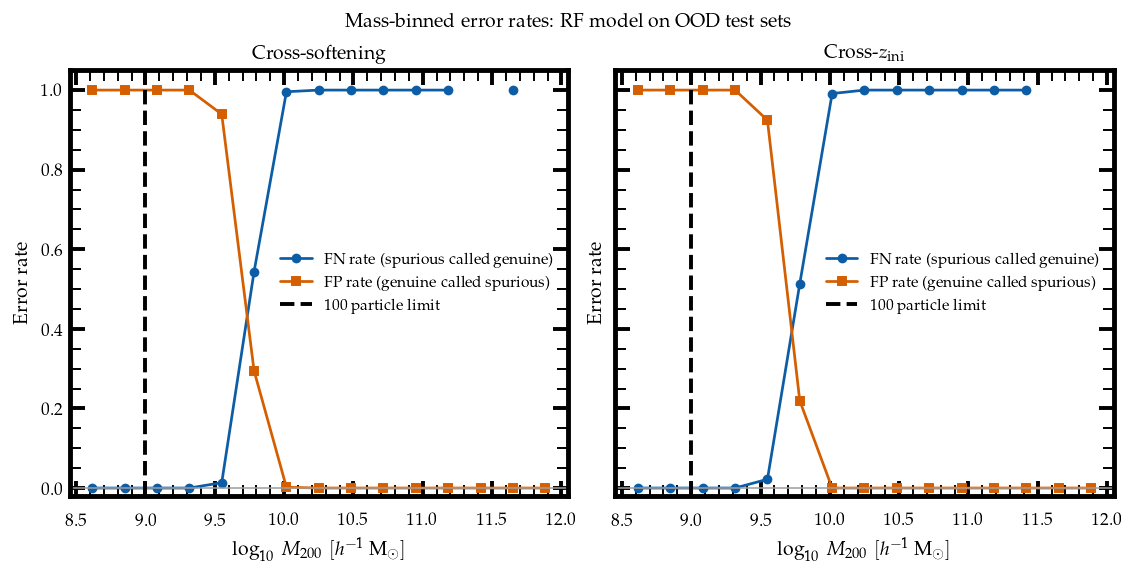

In [9]:
# Mass-binned FN and FP rates for both OOD splits.
# FN rate: fraction of true spurious haloes predicted genuine.
# FP rate: fraction of true genuine haloes predicted spurious.
MASS_BINS = np.linspace(8.5, 12.0, 16)
bin_mids = 0.5 * (MASS_BINS[:-1] + MASS_BINS[1:])

fig, axes = plt.subplots(
    1, 2, figsize=(8, 4),
    constrained_layout=True,
    sharey=True,
)

for ax, split in zip(axes, ood_splits):
    df = test_data[split]
    fn_rates, fp_rates, n_counts = [], [], []

    for lo, hi in zip(MASS_BINS[:-1], MASS_BINS[1:]):
        mask = (df['log10_m200'] >= lo) & (df['log10_m200'] < hi)
        sub = df[mask]
        n_counts.append(len(sub))
        if len(sub) < 5:
            fn_rates.append(np.nan)
            fp_rates.append(np.nan)
            continue
        spur = sub[sub['y_true'] == 1]
        genu = sub[sub['y_true'] == 0]
        fn_rates.append(
            (spur['y_pred'] == 0).mean() if len(spur) > 0 else np.nan
        )
        fp_rates.append(
            (genu['y_pred'] == 1).mean() if len(genu) > 0 else np.nan
        )

    _ = ax.plot(bin_mids, fn_rates, color='#0C5DA5', marker='o',
                markersize=4, linewidth=1.4,
                label='FN rate (spurious called genuine)')
    _ = ax.plot(bin_mids, fp_rates, color='#D55E00', marker='s',
                markersize=4, linewidth=1.4,
                label='FP rate (genuine called spurious)')
    _ = ax.axhline(0, color='#9e9e9e', linewidth=0.8)
    _ = ax.axvline(9, color="k", linestyle="--", label=r"100 particle limit")
    _ = ax.set_xlabel(
        r'$\log_{10}\,M_{200}\ [h^{-1}\,{\rm M}_\odot]$', fontsize=10
    )
    _ = ax.set_ylabel('Error rate', fontsize=10)
    _ = ax.set_title(SPLIT_LABELS[split], fontsize=10)
    _ = ax.set_ylim(-0.02, 1.05)
    _ = ax.legend(fontsize=8)
    _ = ax.tick_params(labelsize=9)

_ = fig.suptitle(
    'Mass-binned error rates: RF model on OOD test sets',
    fontsize=10,
)


**Observations**

- The goal of this section is to diagnose where OOD generalisation errors occur in mass space, and whether that error structure differs between `cross_softening` and `cross_z_ini`.
- In both OOD splits, error behaviour is strongly mass-dependent, with a transition around $\log_{10} M_{200} \approx 9.7\text{--}10.1$ rather than a uniform error profile.
- At the lowest masses ($\log_{10} M_{200} \lesssim 9.5$), the RF predicts almost all haloes as spurious: FN is near zero while FP is near one.
- Near and above the transition mass, the pattern flips toward genuine predictions: FP drops sharply, while FN rises in bins where true spurious haloes still exist.
- At high mass, true spurious counts are small, so FN-rate estimates there are less statistically stable and should be interpreted with count context.
- The two OOD splits show the same qualitative error structure; `cross_softening` is only mildly worse, mainly in the transition bins.

## 4. The cross-$z_{\rm ini}$ non-failure

Mostoghiu Paun et al. (2025) showed that the empirical sphericity relation derived at $z_{\rm ini} = 39$ breaks down at $z_{\rm ini} = 99$ because earlier initialisation shifts all protohalo sphericities downward by ~6%. The predicted consequence was that a classifier trained on z39 data should call many genuine z99 haloes spurious (because their sphericities fell below the z39-derived cut).

However, the average precision on `cross_z_ini` is 0.9828 (RF) versus 0.9852 on `within_sim`, i.e. a drop of 0.0024. This is effectively no degradation.

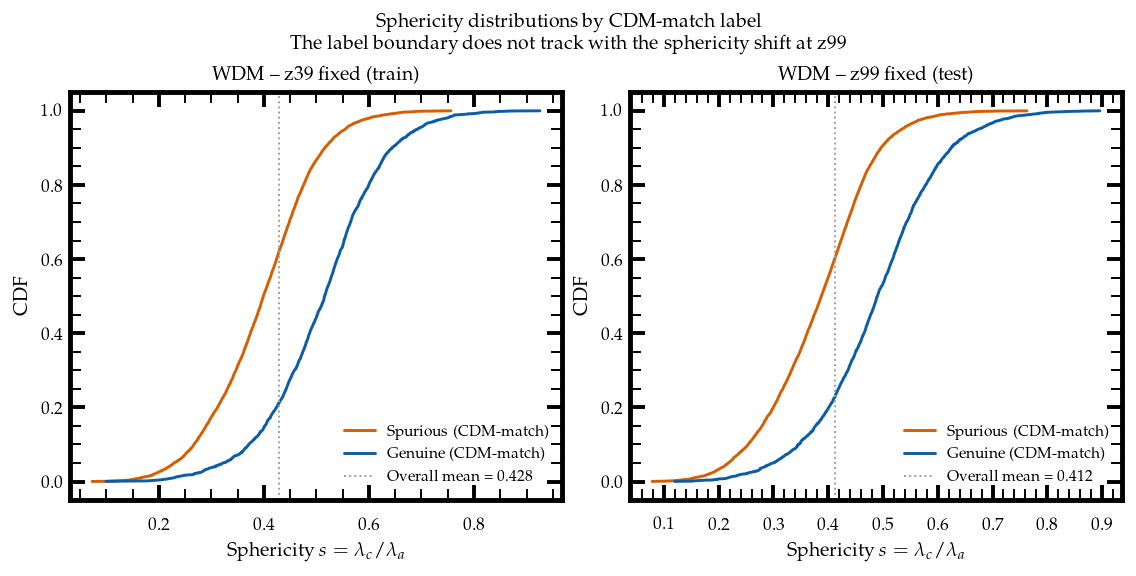

In [10]:
# Sphericity CDFs by CDM-match label for z39 vs z99 WDM simulations.
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

_sims = [
    ('z39_fixed', 'z39 fixed (train)', axes[0]),
    ('z99_fixed', 'z99 fixed (test)',  axes[1]),
]

for sim_key, sim_label, ax in _sims:
    df = frames[sim_key]
    for label_val, color, lbl in [
        (1, '#D55E00', 'Spurious (CDM-match)'),
        (0, '#0C5DA5', 'Genuine (CDM-match)'),
    ]:
        vals = (
            df.loc[df['is_spurious_cdm_match'] == label_val, 'sphericity_s']
            .dropna().values
        )
        if len(vals) == 0:
            continue
        sv = np.sort(vals)
        cdf = np.arange(1, len(sv) + 1) / len(sv)
        _ = ax.plot(sv, cdf, color=color, linewidth=1.5, label=lbl)

    mean_s = df['sphericity_s'].dropna().mean()
    _ = ax.axvline(mean_s, color='#9e9e9e', linestyle=':',
                   linewidth=1, label=f'Overall mean = {mean_s:.3f}')
    _ = ax.set_xlabel(r'Sphericity $s = \lambda_c / \lambda_a$', fontsize=10)
    _ = ax.set_ylabel('CDF', fontsize=10)
    _ = ax.set_title(f'WDM -- {sim_label}', fontsize=10)
    _ = ax.legend(fontsize=8)
    _ = ax.tick_params(labelsize=9)

_ = fig.suptitle(
    'Sphericity distributions by CDM-match label\n'
    'The label boundary does not track with the sphericity shift at z99',
    fontsize=10,
)

In [11]:
# Confirm: are the class proportions (spurious fraction) stable across sims?
_summary_rows = []
for sim_key, sim_id in SIM_IDS.items():
    df = frames[sim_key]
    n_spur = (df['is_spurious_cdm_match'] == 1).sum()
    n_genu = (df['is_spurious_cdm_match'] == 0).sum()
    _summary_rows.append({
        'simulation': sim_key,
        'n_spurious':    n_spur,
        'n_genuine':     n_genu,
        'pct_spurious':  100 * n_spur / len(df),
        'mean_s_spurious': df.loc[df['is_spurious_cdm_match'] == 1, 'sphericity_s'].mean(),
        'mean_s_genuine':  df.loc[df['is_spurious_cdm_match'] == 0, 'sphericity_s'].mean(),
    })

pd.DataFrame(_summary_rows).set_index('simulation').round(3)


,n_spurious,n_genuine,pct_spurious,mean_s_spurious,mean_s_genuine
simulation,,,,,
z39_fixed,15334,3245,82.534,0.396,0.511
z39_adapt,15836,3631,81.348,0.385,0.506
z99_fixed,15192,3234,82.449,0.382,0.489


**Why the failure did not materialise**

The empirical sphericity cut appears unstable at z99 because it was tuned on z39 data: when sphericities shift downward, a fixed threshold can label more genuine z99 haloes as spurious.

The CDM-match label is less exposed to this specific issue because it is defined by particle overlap between WDM and CDM counterpart haloes, rather than morphology.

When the initial redshift changes:

1. WDM and CDM sphericities both shift downward by similar amounts (paper result).
2. The dominant classifier features in this notebook (`log10_m200`, `v_disp_sigv`) change little between z39 and z99.
3. The CDM-match criterion (merit $\geq 0.1$) is independent of protohalo shape.

Taken together, these points suggest that the CDM-match label is comparatively stable under the $z_{\rm ini}$ shift, and that a classifier trained on that label can retain good transfer performance.

Methodologically, this supports the view that the empirical sphericity cut is more configuration-sensitive, while the CDM-match label is more transferable in this OOD test.

## 5. Why cross_softening degrades more than cross_z_ini

The `cross_softening` AP drop from `within_sim` is 0.0087 (RF), whereas the `cross_z_ini` drop is 0.0024. 

Changing the initial redshift is a larger physical perturbation than changing the force softening, so why does softening cause more degradation?

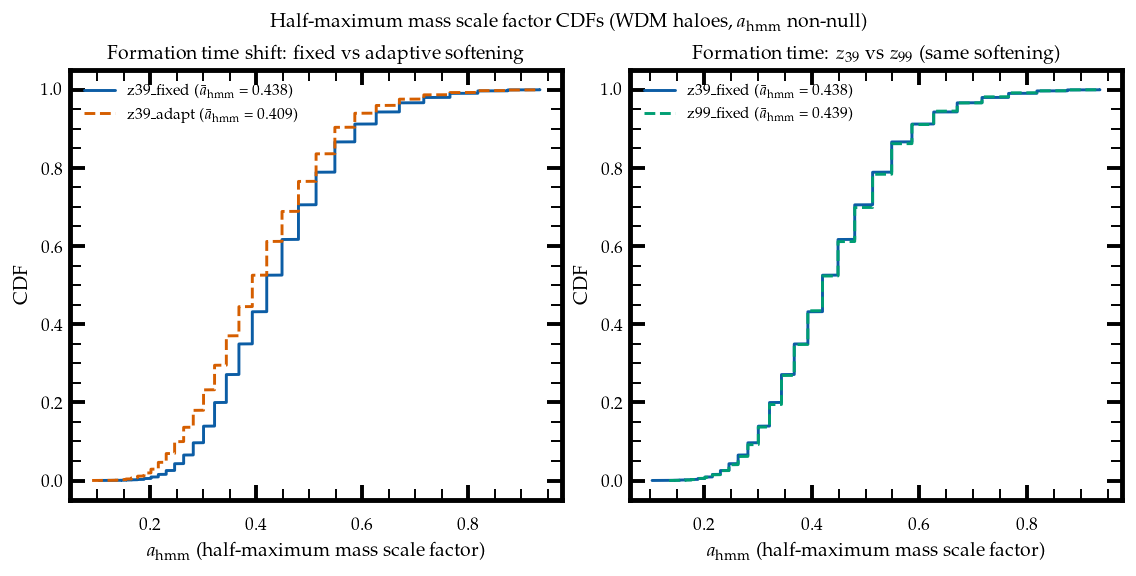

In [12]:
# Formation time (a_hmm) CDFs: fixed vs adaptive (left), z39 vs z99 (right).
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

_panels = [
    (axes[0],
     [('z39_fixed', '#0C5DA5', '-'), ('z39_adapt', '#D55E00', '--')],
     'Formation time shift: fixed vs adaptive softening'),
    (axes[1],
     [('z39_fixed', '#0C5DA5', '-'), ('z99_fixed', '#009E73', '--')],
     r'Formation time: $z_{39}$ vs $z_{99}$ (same softening)'),
]

for ax, sim_list, title in _panels:
    for sim_key, color, ls in sim_list:
        vals = frames[sim_key]['a_hmm'].dropna().values
        sv = np.sort(vals)
        cdf = np.arange(1, len(sv) + 1) / len(sv)
        mean_val = vals.mean()
        _ = ax.plot(
            sv, cdf, color=color, linestyle=ls, linewidth=1.5,
            label=f'{sim_key}  ($\\bar{{a}}_{{\\rm hmm}}$ = {mean_val:.3f})',
        )
    _ = ax.set_xlabel(r'$a_{\rm hmm}$  (half-maximum mass scale factor)', fontsize=10)
    _ = ax.set_ylabel('CDF', fontsize=10)
    _ = ax.set_title(title, fontsize=10)
    _ = ax.legend(fontsize=8)
    _ = ax.tick_params(labelsize=9)

_ = fig.suptitle(
    r'Half-maximum mass scale factor CDFs (WDM haloes, $a_{\rm hmm}$ non-null)',
    fontsize=10,
)


**Interpretation**

The larger `cross_softening` degradation is consistent with two contributing effects:

1. **Formation-time shift**: the tidal adaptive softening run forms WDM haloes slightly earlier ($\Delta\bar{a}_{\rm hmm} \approx 0.03$, consistent with Figure 5 of the paper). Although `a_hmm` ranks low in SHAP importance, population-level shifts in correlated features can still affect calibration.

2. **Harder low-mass test population**: the adaptive run contains more near-threshold haloes, where Section 3 shows errors are concentrated. Using the empirical-cut counts reported in Table 1 of the paper as a proxy, this appears as 61.3% vs 57.1% spurious.

The `cross_z_ini` split shows weaker changes in these specific factors, consistent with its smaller AP drop.

## 6. Summary

| | Cross-softening | Cross-$z_{\rm ini}$ |
|-|-|-|
| AP drop from within-sim (RF) | 0.0087 | 0.0024 |
| Primary distribution shift | $a_{\rm hmm}$ (formation time) | $s$ (sphericity) |
| SHAP rank of shifted feature | ~7-8 (low) | Near-bottom |
| Near-threshold population shift (paper proxy) | Larger | Minimal |
| Spurious-fraction shift (empirical-cut proxy, paper) | 57.1% $\rightarrow$ 61.3% | Minimal |
| Expected failure from empirical-cut intuition | Moderate | Potentially large |
| Observed classifier outcome in this notebook | Modest degradation | Minimal degradation |

**Main conclusions**

1. The classifier generalises well across both OOD splits in this study, likely because its primary signals (`log10_m200`, `v_disp_sigv`) are comparatively stable across these simulation configurations.

2. The CDM-match label appears more robust to the $z_{\rm ini}$ shift than the empirical sphericity cut. Decoupling labels from morphology may improve transferability.

3. The `cross_softening` degradation is real but modest, and is consistent with a formation-time shift plus a somewhat harder low-mass population.

4. RF is the strongest single-model choice in these experiments, whereas the ensemble provides limited additional benefit.